# Experiment 04 — Pixels versus embeddings

**Question:** What changes when two models see the same masked images but predict different targets?

One model predicts hidden RGB values. The other predicts hidden target-encoder vectors. We hold the data, mask, encoder size, optimizer, and training budget fixed wherever possible.

## Our prediction

The pixel model should preserve information useful for reconstructing colour and texture. JEPA may learn representations that group semantically related images more clearly, but its moving target also creates a risk of representation collapse.

In [1]:
from pathlib import Path
import sys

project_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists()),
    None,
)
if project_root is None:
    raise RuntimeError('Could not find the JEPA Experiments project root')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
project_root

PosixPath('/Users/houstonmuzamhindo/Desktop/Startups/Books/JEPA Experiments')

In [2]:
import matplotlib.pyplot as plt
import torch
from torch.nn import functional as F
from torch.optim import AdamW
from torch.utils.data import DataLoader, Subset

from jepa.data import load_cifar10
from jepa.device import best_device
from jepa.evaluation import diversity_metrics, nearest_neighbour_label_agreement
from jepa.masking import centered_block_mask
from jepa.models import PatchAutoencoder, TinyJEPA, masked_embedding_loss, masked_pixel_loss

torch.manual_seed(7)
device = best_device()
device

device(type='mps')

## 1. Hold the important choices fixed

Both models train on the first 10,000 CIFAR-10 training images for five epochs. Both receive a central mask covering 16 of 64 patches. Their encoders use four transformer blocks, four attention heads, and 128-number tokens. CIFAR-10 labels are withheld during training.

In [3]:
TRAINING_IMAGES = 10_000
TEST_IMAGES = 1_000
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 3e-4
EMBEDDING_DIM = 128
mask = centered_block_mask(8, 4, device=device)

train_data = Subset(load_cifar10(train=True), range(TRAINING_IMAGES))
test_data = Subset(load_cifar10(train=False), range(TEST_IMAGES))
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=0)
first_batch, _ = next(iter(train_loader))
print('Training images:', len(train_data))
print('Held-out images:', len(test_data))
print('Hidden patches:', int(mask.sum()))

Training images: 10000
Held-out images: 1000
Hidden patches: 16


## 2. Build both models

The encoder dimensions match. JEPA has an additional two-block predictor, so its trainable parameter count is larger. We print that difference rather than pretending the complete models are identical.

In [4]:
pixel_model = PatchAutoencoder(embedding_dim=EMBEDDING_DIM).to(device)
jepa_model = TinyJEPA(embedding_dim=EMBEDDING_DIM, ema_decay=0.99).to(device)

pixel_parameters = sum(p.numel() for p in pixel_model.parameters() if p.requires_grad)
jepa_parameters = sum(p.numel() for p in jepa_model.parameters() if p.requires_grad)
print(f'Pixel model trainable parameters: {pixel_parameters:,}')
print(f'JEPA trainable parameters:        {jepa_parameters:,}')

/Users/houstonmuzamhindo/Desktop/Startups/Books/JEPA Experiments/jepa/models.py:46: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=depth, norm=nn.LayerNorm(embedding_dim))
/Users/houstonmuzamhindo/Desktop/Startups/Books/JEPA Experiments/jepa/models.py:106: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
/Users/houstonmuzamhindo/Desktop/Startups/Books/JEPA Experiments/jepa/models.py:142: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Pixel model trainable parameters: 814,128
JEPA trainable parameters:        1,229,440


## 3. Train the pixel model

Its loss is mean squared error over the 768 hidden RGB values in each image.

In [5]:
pixel_optimizer = AdamW(pixel_model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
pixel_losses = []

pixel_model.eval()
with torch.no_grad():
    predicted, target = pixel_model(first_batch.to(device), mask)
    pixel_initial_loss = masked_pixel_loss(predicted, target, mask).item()
print(f'Initial pixel loss: {pixel_initial_loss:.6f}')

for epoch in range(EPOCHS):
    pixel_model.train()
    total = 0.0
    seen = 0
    for images, _ in train_loader:
        images = images.to(device)
        predicted, target = pixel_model(images, mask)
        loss = masked_pixel_loss(predicted, target, mask)
        pixel_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        pixel_optimizer.step()
        total += loss.item() * images.shape[0]
        seen += images.shape[0]
    pixel_losses.append(total / seen)
    print(f'Pixel epoch {epoch + 1:02d}/{EPOCHS}: {pixel_losses[-1]:.6f}')

Initial pixel loss: 0.683755
Pixel epoch 01/5: 0.070661
Pixel epoch 02/5: 0.055578
Pixel epoch 03/5: 0.052278
Pixel epoch 04/5: 0.047298
Pixel epoch 05/5: 0.039632


## 4. Train JEPA

Its loss is normalized mean squared error over 128-number target vectors at the same 16 hidden positions. We also record cosine similarity.

In [6]:
jepa_optimizer = AdamW(
    list(jepa_model.context_encoder.parameters()) + list(jepa_model.predictor.parameters()),
    lr=LEARNING_RATE,
    weight_decay=0.05,
)
jepa_losses = []
jepa_similarities = []

jepa_model.eval()
with torch.no_grad():
    predicted, target = jepa_model.predict(first_batch.to(device), mask)
    jepa_initial_loss = masked_embedding_loss(predicted, target, mask).item()
print(f'Initial JEPA loss: {jepa_initial_loss:.6f}')

for epoch in range(EPOCHS):
    jepa_model.train()
    total_loss = 0.0
    total_similarity = 0.0
    seen = 0
    for images, _ in train_loader:
        images = images.to(device)
        predicted, target = jepa_model.predict(images, mask)
        loss = masked_embedding_loss(predicted, target, mask)
        jepa_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        jepa_optimizer.step()
        jepa_model.update_target()
        count = images.shape[0]
        total_loss += loss.item() * count
        total_similarity += F.cosine_similarity(
            predicted[:, mask].detach(), target[:, mask], dim=-1
        ).mean().item() * count
        seen += count
    jepa_losses.append(total_loss / seen)
    jepa_similarities.append(total_similarity / seen)
    print(
        f'JEPA epoch {epoch + 1:02d}/{EPOCHS}: loss={jepa_losses[-1]:.6f}, '
        f'cosine={jepa_similarities[-1]:.4f}'
    )

Initial JEPA loss: 0.017208
JEPA epoch 01/5: loss=0.000764, cosine=0.9511
JEPA epoch 02/5: loss=0.000165, cosine=0.9895
JEPA epoch 03/5: loss=0.000145, cosine=0.9907
JEPA epoch 04/5: loss=0.000155, cosine=0.9901
JEPA epoch 05/5: loss=0.000197, cosine=0.9874


## 5. Compare learning progress without mixing units

Pixel MSE and embedding MSE have different meanings and scales. Dividing each epoch loss by that model’s untrained loss lets us compare how much of its starting error remains.

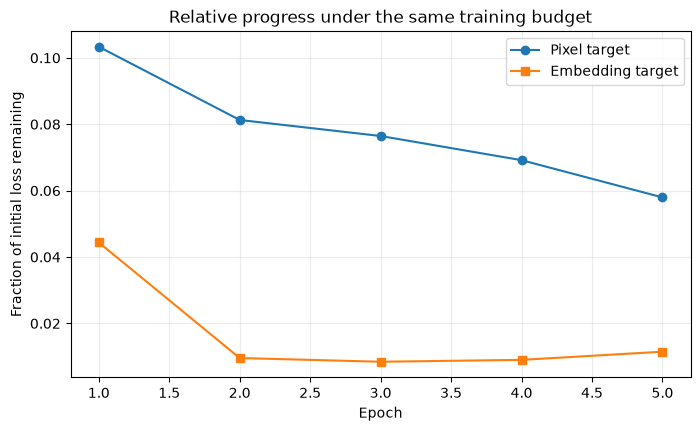

In [7]:
epochs = range(1, EPOCHS + 1)
plt.figure(figsize=(8, 4.5))
plt.plot(epochs, [loss / pixel_initial_loss for loss in pixel_losses], marker='o', label='Pixel target')
plt.plot(epochs, [loss / jepa_initial_loss for loss in jepa_losses], marker='s', label='Embedding target')
plt.xlabel('Epoch')
plt.ylabel('Fraction of initial loss remaining')
plt.title('Relative progress under the same training budget')
plt.grid(alpha=0.25)
plt.legend();

## 6. Evaluate on unseen images

Training fit can hide memorization. We calculate each model’s own prediction measurement on 1,000 test images that neither model saw during training. The two numbers still should not be compared directly with each other.

In [8]:
pixel_model.eval()
jepa_model.eval()
pixel_test_total = 0.0
jepa_test_total = 0.0
jepa_test_cosine = 0.0
test_seen = 0

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        pixel_predicted, pixel_target = pixel_model(images, mask)
        jepa_predicted, jepa_target = jepa_model.predict(images, mask)
        count = images.shape[0]
        pixel_test_total += masked_pixel_loss(pixel_predicted, pixel_target, mask).item() * count
        jepa_test_total += masked_embedding_loss(jepa_predicted, jepa_target, mask).item() * count
        jepa_test_cosine += F.cosine_similarity(
            jepa_predicted[:, mask], jepa_target[:, mask], dim=-1
        ).mean().item() * count
        test_seen += count

print(f'Pixel test MSE:       {pixel_test_total / test_seen:.6f}')
print(f'JEPA test loss:       {jepa_test_total / test_seen:.6f}')
print(f'JEPA test cosine:     {jepa_test_cosine / test_seen:.4f}')

Pixel test MSE:       0.034667
JEPA test loss:       0.000222
JEPA test cosine:     0.9858


## 7. Compare the representations

We now give both encoders complete, unmasked test images. We measure whether their patch vectors retain variation across features, patches, and images.

In [9]:
pixel_token_batches = []
jepa_token_batches = []
label_batches = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        pixel_token_batches.append(pixel_model.encode(images).cpu())
        jepa_token_batches.append(jepa_model.target_encoder(images).cpu())
        label_batches.append(labels)

pixel_tokens = torch.cat(pixel_token_batches)
jepa_tokens = torch.cat(jepa_token_batches)
test_labels = torch.cat(label_batches)
pixel_diversity = diversity_metrics(pixel_tokens)
jepa_diversity = diversity_metrics(jepa_tokens)

print('Measurement'.ljust(32), 'Pixel'.rjust(10), 'JEPA'.rjust(10))
for key in pixel_diversity:
    print(key.ljust(32), f'{pixel_diversity[key]:10.4f}', f'{jepa_diversity[key]:10.4f}')

Measurement                           Pixel       JEPA
feature_std                          0.0155     0.0393
within_image_similarity              0.9973     0.9925
across_image_similarity              0.9702     0.7812
effective_rank                      38.0601    21.6215


## 8. Ask whether nearby images share a label

We average each image’s 64 patch vectors into one image vector. For every test image, we find the closest other image and check whether their CIFAR-10 labels match. Labels are used only for this evaluation. Random agreement is roughly 10% because there are ten balanced classes. This is an early diagnostic, not a replacement for the linear probe in Experiment 05.

In [10]:
pixel_vectors = pixel_tokens.mean(dim=1)
jepa_vectors = jepa_tokens.mean(dim=1)
pixel_agreement = nearest_neighbour_label_agreement(pixel_vectors, test_labels)
jepa_agreement = nearest_neighbour_label_agreement(jepa_vectors, test_labels)

print(f'Random reference:                  about 10.0%')
print(f'Pixel representation agreement:   {pixel_agreement:.1%}')
print(f'JEPA representation agreement:    {jepa_agreement:.1%}')

Random reference:                  about 10.0%
Pixel representation agreement:   18.3%
JEPA representation agreement:    16.5%


## What happened in this run

### Both models learned their own targets

The pixel model reduced its loss from `0.683755` before training to `0.039632` at epoch 5, leaving about 5.8% of its starting error. JEPA fell from `0.017208` to a best value of `0.000145` at epoch 3. Its loss then rose slightly to `0.000197` at epoch 5, leaving about 1.1% of its starting error. JEPA matched its moving target faster, but the late reversal from Experiment 03 appeared again.

These relative curves are useful but imperfect. Each starting value came from one batch, each epoch value is an average, dropout is active during training, and JEPA’s EMA target changes over time.

### Both objectives transferred to held-out images

On 1,000 unseen images, the pixel model obtained MSE `0.034667`. JEPA obtained embedding loss `0.000222` and cosine similarity `0.9858`. These values show that both models could predict their own targets outside the training subset. The pixel and embedding losses still cannot be compared numerically with one another.

### The diversity result was mixed

JEPA had greater feature variation (`0.0393` versus `0.0155`) and much lower similarity across different images (`0.7812` versus `0.9702`). By those measurements, JEPA distinguished images more clearly. The pixel representation had a higher effective rank (`38.06` versus `21.62`), meaning its variation occupied more independent directions. Patches inside the same image were extremely similar for both models (`0.9973` for pixels and `0.9925` for JEPA).

This does not look like complete JEPA collapse: different images are not all mapped to the same direction. It does show that JEPA uses a relatively low-dimensional part of its 128-dimensional space.

### JEPA did not win the first semantic check

Nearest-neighbour label agreement was `18.3%` for the pixel representation and `16.5%` for JEPA, compared with a random reference of roughly `10%`. Both representations contain some class-related structure, but the pixel model was slightly higher in this one run. With only 1,000 images, one seed, and nearest-neighbour evaluation, the 1.8 percentage-point gap is too small to support a broad claim that the pixel objective is better.

## What we learned

Changing the target changed the geometry of the learned space. JEPA separated whole images more strongly but concentrated that variation into fewer directions. The pixel model used more directions and produced slightly better nearest-neighbour class agreement. Our prediction that JEPA would immediately produce the more semantic representation was not supported by this experiment.

There is no clear winner yet. Experiment 05 will replace the nearest-neighbour shortcut with linear probes trained on frozen representations, repeated under controlled conditions.